In [7]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import zipfile
with zipfile.ZipFile('netflix_titles.csv.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

In [8]:
df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [9]:
conn = sqlite3.connect('netflix.db')
df.to_sql('netflix', conn, if_exists='replace', index=False)
print("Data loaded successfully!")

Data loaded successfully!


In [11]:
query = """
SELECT type, COUNT(*) as total
FROM netflix
GROUP BY type
"""
result = pd.read_sql_query(query, conn)
print("How many Movies vs TV Shows are there?")
print(result)

How many Movies vs TV Shows are there?
      type  total
0    Movie   6131
1  TV Show   2676


In [12]:
query = """
SELECT country, COUNT(*) as total
FROM netflix
WHERE country IS NOT NULL
GROUP BY country
ORDER BY total DESC
LIMIT 10
"""
result = pd.read_sql_query(query, conn)
print("Which countries produce the most content?")
print(result)

Which countries produce the most content?
          country  total
0   United States   2818
1           India    972
2  United Kingdom    419
3           Japan    245
4     South Korea    199
5          Canada    181
6           Spain    145
7          France    124
8          Mexico    110
9           Egypt    106


In [13]:
query = """
SELECT listed_in, COUNT(*) as total
FROM netflix
GROUP BY listed_in
ORDER BY total DESC
LIMIT 10
"""
result = pd.read_sql_query(query, conn)
print("Which genres appear most often?")
print(result)

Which genres appear most often?
                                          listed_in  total
0                      Dramas, International Movies    362
1                                     Documentaries    359
2                                   Stand-Up Comedy    334
3            Comedies, Dramas, International Movies    274
4  Dramas, Independent Movies, International Movies    252
5                                          Kids' TV    220
6                          Children & Family Movies    215
7                Children & Family Movies, Comedies    201
8               Documentaries, International Movies    186
9     Dramas, International Movies, Romantic Movies    180


In [14]:
query = """
SELECT release_year, COUNT(*) as total
FROM netflix
WHERE release_year BETWEEN 2010 AND 2021
GROUP BY release_year
ORDER BY release_year
"""
result = pd.read_sql_query(query, conn)
print("How much content was added each year?")
print(result)

How much content was added each year?
    release_year  total
0           2010    194
1           2011    185
2           2012    237
3           2013    288
4           2014    352
5           2015    560
6           2016    902
7           2017   1032
8           2018   1147
9           2019   1030
10          2020    953
11          2021    592


In [15]:
query = """
SELECT rating, COUNT(*) as total
FROM netflix
WHERE rating IS NOT NULL
GROUP BY rating
ORDER BY total DESC
"""
result = pd.read_sql_query(query, conn)
print("What are the most common ratings?")
print(result)

What are the most common ratings?
      rating  total
0      TV-MA   3207
1      TV-14   2160
2      TV-PG    863
3          R    799
4      PG-13    490
5      TV-Y7    334
6       TV-Y    307
7         PG    287
8       TV-G    220
9         NR     80
10         G     41
11  TV-Y7-FV      6
12        UR      3
13     NC-17      3
14    84 min      1
15    74 min      1
16    66 min      1


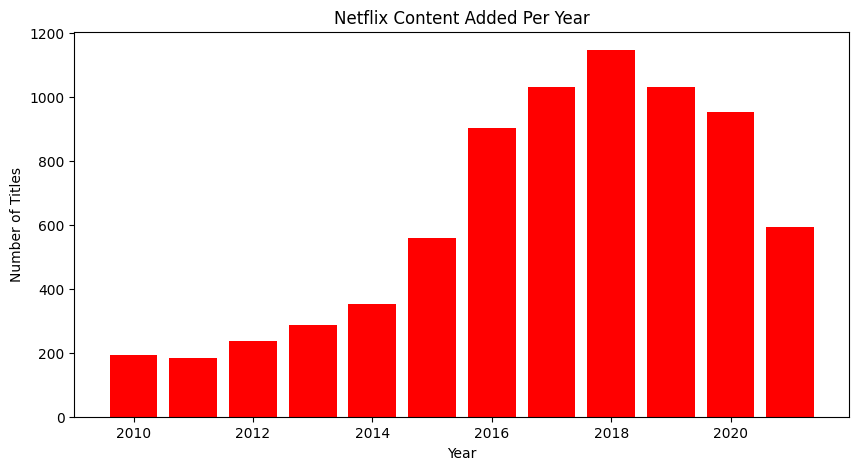

In [17]:
query = """
SELECT release_year, COUNT(*) as total
FROM netflix
WHERE release_year BETWEEN 2010 AND 2021
GROUP BY release_year
ORDER BY release_year
"""
result = pd.read_sql_query(query, conn)

plt.figure(figsize=(10,5))
plt.bar(result['release_year'], result['total'], color='red')
plt.title('Netflix Content Added Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()